# Multi-Armed Bandits

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from gymnasium import spaces
sns.set_style('dark')
sns.set_context('notebook')

# creates class to store the multi-arm bandit (MAB) environment
class BanditEnv(gym.Env):
    def __init__(self, k=10):
        super().__init__()
        self.k = k
        self.action_space = spaces.Discrete(k)
        self.observation_space = spaces.Discrete(1)
        # True reward means sampled from N(0, 1)
        self.means = np.random.normal(0, 1, k) # Gaussian random sampling
        self.best_action = np.argmax(self.means)

    # reset environment
    def reset(self, seed=5, options=None):
        super().reset(seed=seed)
        return 0, {}

    # take random action from Gaussian distribution
    def step(self, action):
        # Reward is N(mean, 1)
        reward = np.random.normal(self.means[action], 1)
        return 0, reward, False, False, {"is_optimal": action == self.best_action}

In [10]:
# defines the custom MAB agent
class BanditAgent:
    def __init__(self, k=10):
        self.k = k
        self.n = np.zeros(k) # Action counts
        self.q = np.zeros(k) # Estimated values
        self.t = 0

    def update(self, action, reward):
        self.t += 1
        self.n[action] += 1
        # Incremental update: Q = Q + 1/n * (R - Q)
        self.q[action] += (reward - self.q[action]) / self.n[action]

# defines the random epsilon-greedy agent
class EpsilonGreedyAgent(BanditAgent):
    def __init__(self, k=10, epsilon=0.1):
        super().__init__(k)
        self.epsilon = epsilon

    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.k)
        return np.argmax(self.q)

# defines the random UCB agent
class UCBAgent(BanditAgent):
    def __init__(self, k=10, c=2):
        super().__init__(k)
        self.c = c

    def get_action(self):
        if 0 in self.n: # Ensure every arm is pulled once
            return np.where(self.n == 0)[0][0]
        
        confidence_bound = self.c * np.sqrt(np.log(self.t) / self.n)
        return np.argmax(self.q + confidence_bound)

# inspect the given environment
def inspect_env(env_name):
    env = gym.make(env_name)
    print(f"--- Detailed Inspection: {env_name} ---")
    
    # 1. Action Space Inspection
    print(f"Action Space: {env.action_space}")
    if isinstance(env.action_space, gym.spaces.Discrete):
        print(f"  - Type: Discrete")
        print(f"  - Dimensions: 1 (Scalar index)")
        print(f"  - Bounds: [0, {env.action_space.n - 1}]")
    elif isinstance(env.action_space, gym.spaces.Box):
        print(f"  - Type: Continuous (Box)")
        print(f"  - Dimensions/Shape: {env.action_space.shape}")
        print(f"  - Low Bounds: {env.action_space.low}")
        print(f"  - High Bounds: {env.action_space.high}")

    # 2. Observation Space Inspection
    print(f"Observation Space: {env.observation_space}")
    if isinstance(env.observation_space, gym.spaces.Discrete):
        print(f"  - Type: Discrete")
        print(f"  - Dimensions: 1 (Scalar index)")
        print(f"  - Bounds: [0, {env.observation_space.n - 1}]")
    elif isinstance(env.observation_space, gym.spaces.Box):
        print(f"  - Type: Continuous (Box)")
        print(f"  - Dimensions/Shape: {env.observation_space.shape}")
        print(f"  - Low Bounds: {env.observation_space.low}")
        print(f"  - High Bounds: {env.observation_space.high}")

    # 3. Random Policy Agent Performance
    obs, _ = env.reset(seed=5)
    total_reward = 0
    steps = 0
    for _ in range(200): # Increased steps for environments like Taxi
        action = env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
        if terminated or truncated:
            break
    print(f"Random Agent Performance: Reward = {total_reward}, Steps = {steps}")
    print("-" * 40 + "\n")
    env.close()

## Evaluation

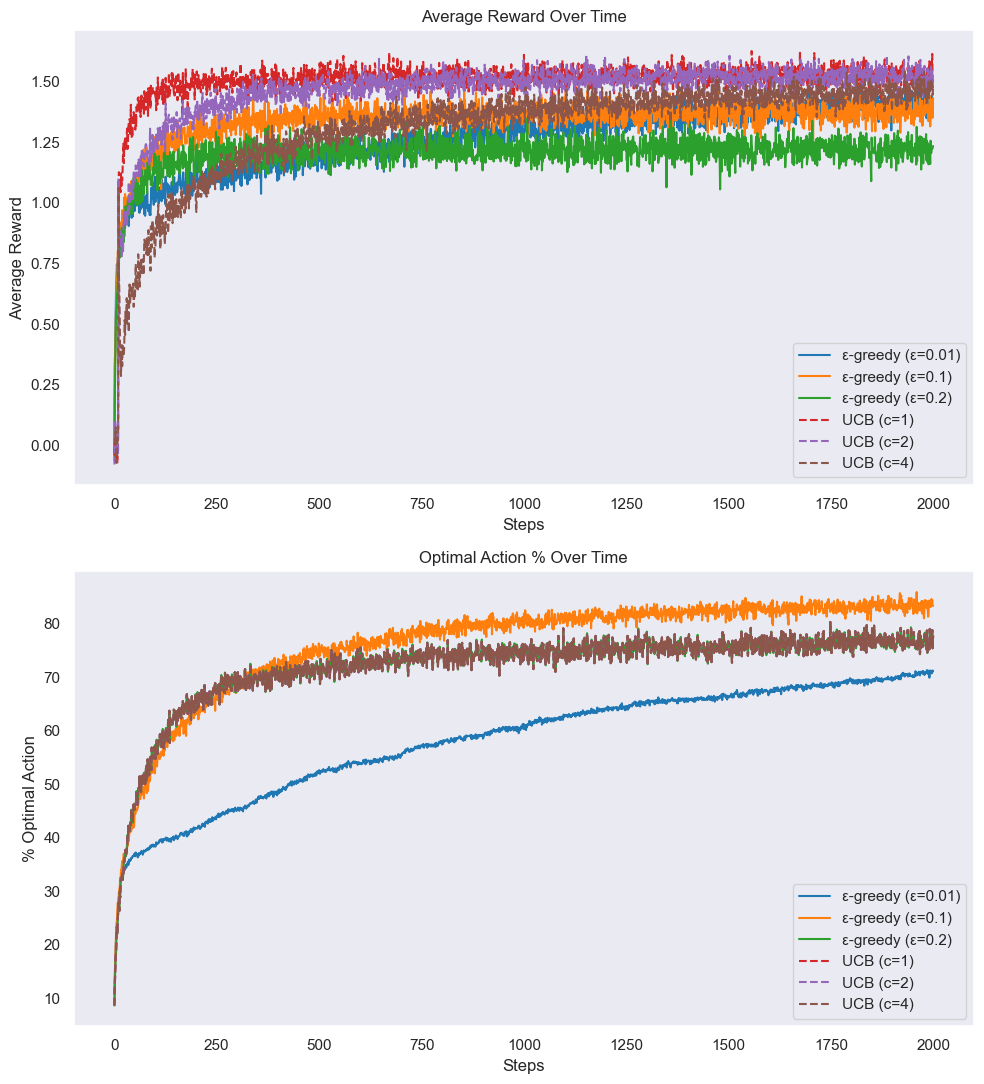

In [3]:
# trains the agents on custom bandit environment
def run_experiment(agent_class, env_k=10, steps=2000, runs=1000, **kwargs):
    all_rewards = np.zeros((runs, steps))
    optimal_counts = np.zeros((runs, steps))

    for r in range(runs):
        env = BanditEnv(k=env_k)
        agent = agent_class(k=env_k, **kwargs)
        env.reset()
        
        for t in range(steps):
            action = agent.get_action()
            _, reward, _, _, info = env.step(action)
            agent.update(action, reward)
            
            all_rewards[r, t] = reward
            if info['is_optimal']:
                optimal_counts[r, t] = 1
                
    return all_rewards.mean(axis=0), optimal_counts.mean(axis=0)

# plot
plt.figure(figsize=(10, 11))
plt.subplot(2, 1, 1)

# subplot 1: average reward
for eps in [0.01, 0.1, 0.2]:
    rew, _ = run_experiment(EpsilonGreedyAgent, epsilon=eps)
    plt.plot(rew, label=f'ε-greedy (ε={eps})')

for c_val in [1, 2, 4]:
    rew, _ = run_experiment(UCBAgent, c=c_val)
    plt.plot(rew, label=f'UCB (c={c_val})', linestyle='--')

plt.title('Average Reward Over Time')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.legend()

# subplot 2: optimal action %
plt.subplot(2, 1, 2)
for eps in [0.01, 0.1, 0.2]:
    _, opt = run_experiment(EpsilonGreedyAgent, epsilon=eps)
    plt.plot(opt * 100, label=f'ε-greedy (ε={eps})')

for c_val in [1, 2, 4]:
    # _, opt = run_experiment(UCBAgent, c=c_val)
    plt.plot(opt * 100, label=f'UCB (c={c_val})', linestyle='--')

plt.title('Optimal Action % Over Time')
plt.xlabel('Steps')
plt.ylabel('% Optimal Action')
plt.legend()

plt.tight_layout()
plt.savefig('history.png')
plt.show()

### Reward Distributions

/var/folders/lg/qjz9rnn97jq8zysv08gn0bm80000gn/T/ipykernel_99289/2764495002.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Arm', y='Reward', data=plot_df, inner='quartile', palette='muted')


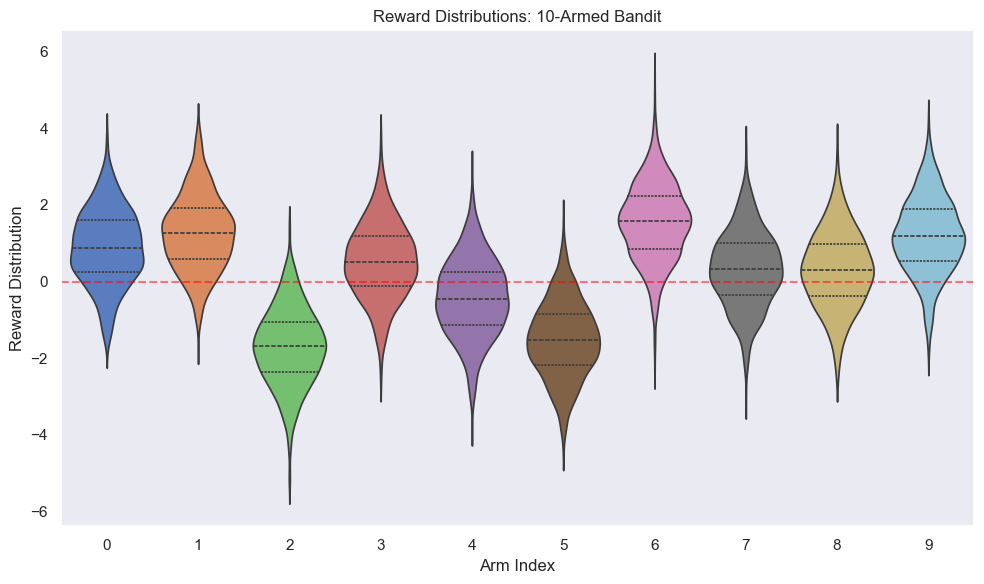

In [4]:
bandit_env = BanditEnv(k=10) # re-define environment for plotting
def plot_bandit_distributions(env):
    data = []
    # attributes stored in bandit class
    for i in range(env.k):
        rewards = np.random.normal(env.means[i], 1, 1000) # sample 1000 rewards per arm
        for r in rewards:
            data.append({'Arm': i, 'Reward': r})
    
    plot_df = pd.DataFrame(data)
    
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Arm', y='Reward', data=plot_df, inner='quartile', palette='muted')
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    plt.title(f'Reward Distributions: {env.k}-Armed Bandit')
    plt.xlabel('Arm Index')
    plt.ylabel('Reward Distribution')

    plt.tight_layout()
    plt.savefig('rewards.png')
    plt.show()

# plot the bandit environment distribution
plot_bandit_distributions(bandit_env)

## Inspect Environments

In [14]:
# inspect frozenlake and taxi environments
inspect_env("FrozenLake-v1")
inspect_env("Taxi-v3")

--- Detailed Inspection: FrozenLake-v1 ---
Action Space: Discrete(4)
  - Type: Discrete
  - Dimensions: 1 (Scalar index)
  - Bounds: [0, 3]
Observation Space: Discrete(16)
  - Type: Discrete
  - Dimensions: 1 (Scalar index)
  - Bounds: [0, 15]
Random Agent Performance: Reward = 0, Steps = 3
----------------------------------------

--- Detailed Inspection: Taxi-v3 ---
Action Space: Discrete(6)
  - Type: Discrete
  - Dimensions: 1 (Scalar index)
  - Bounds: [0, 5]
Observation Space: Discrete(500)
  - Type: Discrete
  - Dimensions: 1 (Scalar index)
  - Bounds: [0, 499]
Random Agent Performance: Reward = -767, Steps = 200
----------------------------------------

